# Credit Card Fraud Detection

## Project Overview

This project builds a machine-learning system to detect fraudulent credit card transactions.

The notebook covers:
- Data loading and understanding
- Exploratory data analysis (EDA)
- Class-imbalance analysis
- Data preprocessing
- SMOTE-based oversampling for Logistic Regression
- Logistic Regression, Decision Tree, and Random Forest models
- Model evaluation using classification metrics
- ROC and Precision-Recall curves
- Random Forest feature importance
- Saving the trained model and preprocessing objects
- Testing a sample transaction

**Target variable:** `Class`  
- `0` = Legitimate transaction
- `1` = Fraudulent transaction


## 1. Import Required Libraries

In [1]:
# Import libraries required for data analysis, visualization,
# preprocessing, machine learning, evaluation, and model saving.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Load the Dataset

The dataset file `creditcard.csv` must be placed in the same folder as this notebook.

In [49]:
# Load the credit card transaction dataset.
df = pd.read_csv("creditcard.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Understand the Dataset

In [3]:
# Display the number of rows and columns.
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 284807
Columns: 31


In [4]:
# Display the first five records.
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Display the last five records.
df.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
# Display all column names and their positions.
print("Columns:")

for i, column in enumerate(df.columns):
    print(i, ":", column)


Columns:
0 : Time
1 : V1
2 : V2
3 : V3
4 : V4
5 : V5
6 : V6
7 : V7
8 : V8
9 : V9
10 : V10
11 : V11
12 : V12
13 : V13
14 : V14
15 : V15
16 : V16
17 : V17
18 : V18
19 : V19
20 : V20
21 : V21
22 : V22
23 : V23
24 : V24
25 : V25
26 : V26
27 : V27
28 : V28
29 : Amount
30 : Class


In [7]:
# Display data types and non-null counts.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
# Display descriptive statistics for numerical columns.
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 4. Check Missing Values and Duplicate Records

In [9]:
# Check the number of missing values in each column.
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])


Missing values:
Series([], dtype: int64)


In [10]:
# Calculate the total number of missing values.
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


In [11]:
# Check for duplicate transaction records.
print("Duplicate records:", df.duplicated().sum())


Duplicate records: 1081


In [12]:
# Remove duplicate records before further analysis.
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (283726, 31)


## 5. Analyze Class Distribution

In [13]:
# Count legitimate and fraudulent transactions.
print(df["Class"].value_counts())


Class
0    283253
1       473
Name: count, dtype: int64


In [14]:
# Calculate the percentage of each transaction class.
class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    * 100
)

print(class_percentage)


Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [15]:
# Calculate the number and percentage of legitimate and fraudulent transactions.
normal_count = (df["Class"] == 0).sum()
fraud_count = (df["Class"] == 1).sum()
total_count = len(df)

print("Total Transactions :", total_count)
print("Legitimate         :", normal_count)
print("Fraud              :", fraud_count)
print(
    "Fraud Percentage   :",
    round((fraud_count / total_count) * 100, 4),
    "%"
)


Total Transactions : 283726
Legitimate         : 283253
Fraud              : 473
Fraud Percentage   : 0.1667 %


## 6. Exploratory Data Analysis

The following visualizations help examine the transaction classes, transaction amounts, and relationships between numerical variables.

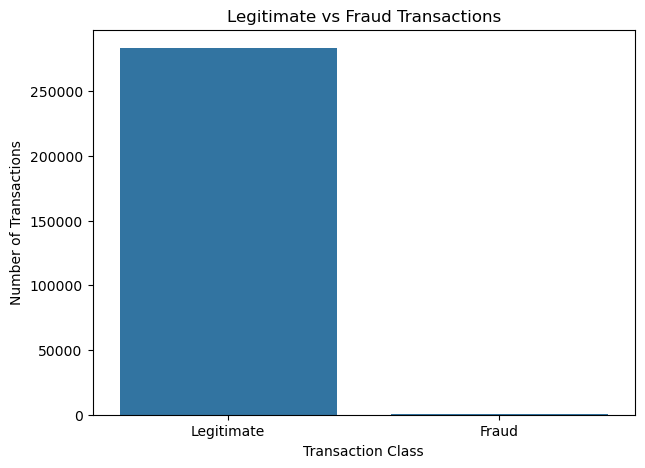

In [16]:
# Visualize the number of legitimate and fraudulent transactions.
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Legitimate vs Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()


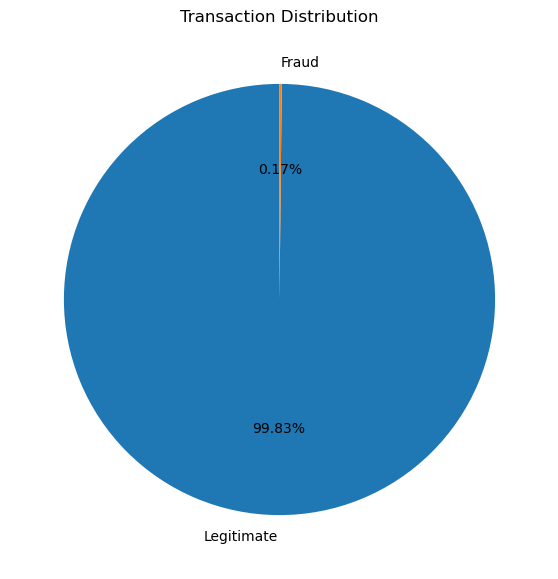

In [17]:
# Visualize the proportion of legitimate and fraudulent transactions.
labels = ["Legitimate", "Fraud"]
sizes = [normal_count, fraud_count]

plt.figure(figsize=(7, 7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Transaction Distribution")
plt.show()


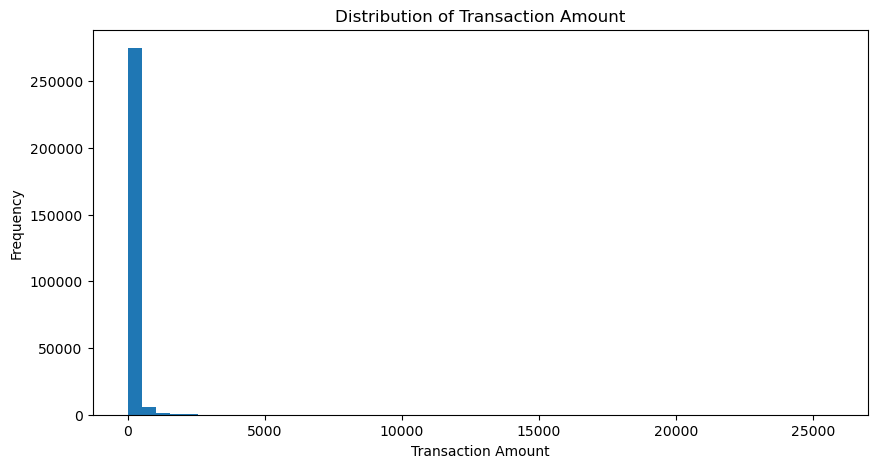

In [18]:
# Examine the distribution of transaction amounts.
plt.figure(figsize=(10, 5))

plt.hist(
    df["Amount"],
    bins=50
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")

plt.show()


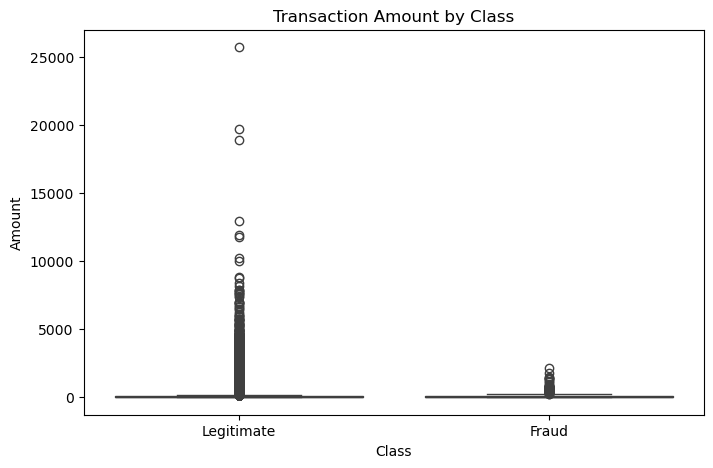

In [19]:
# Compare transaction amounts between legitimate and fraudulent transactions.
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Transaction Amount by Class")

plt.show()


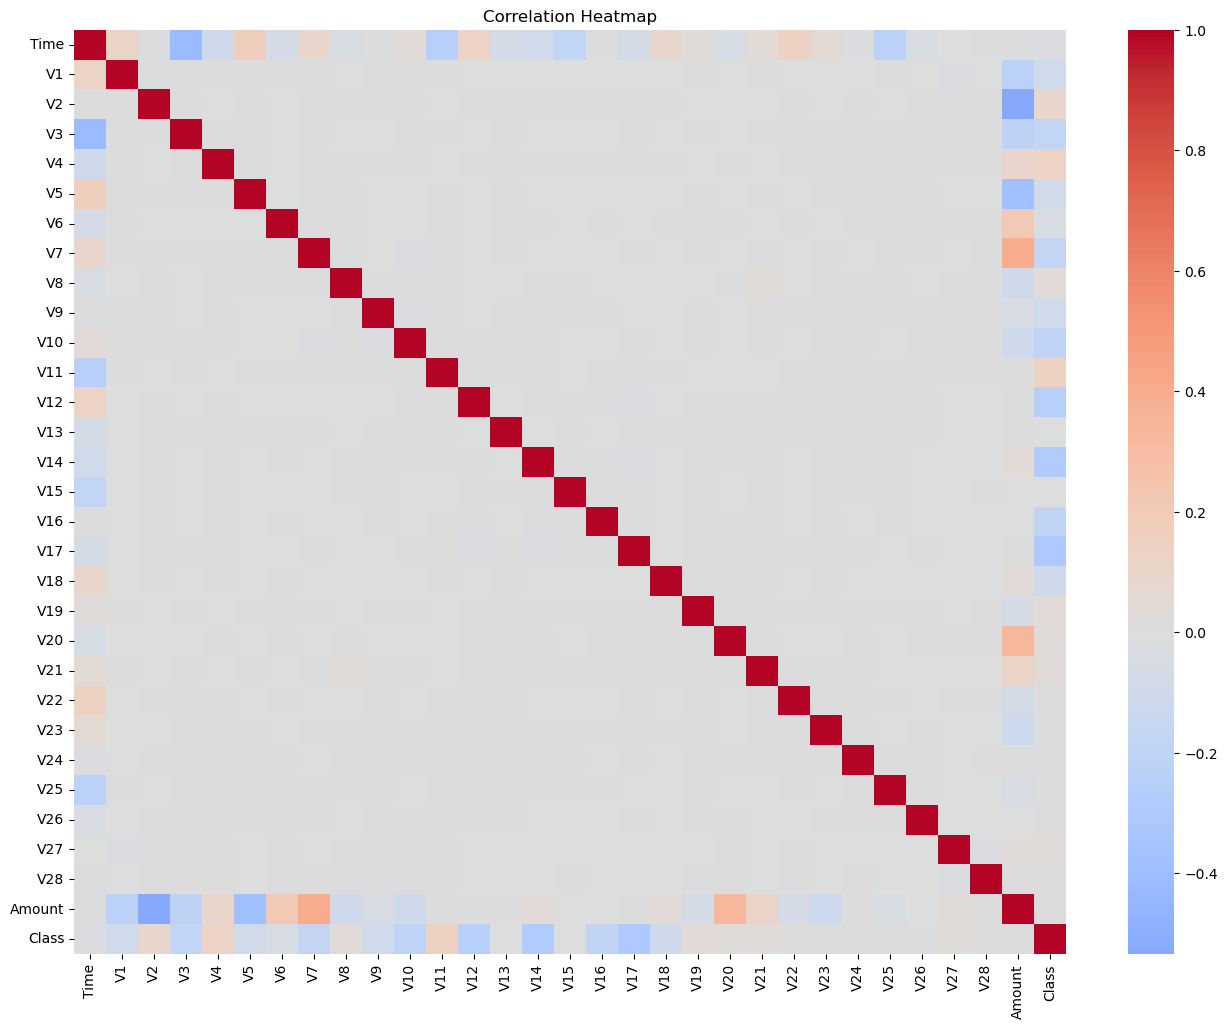

In [20]:
# Examine correlations among the numerical features.
correlation = df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()


## 7. Prepare Features and Target

In [21]:
# Separate the input features from the target variable.
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (283726, 30)
y shape: (283726,)


## 8. Split the Data

The data is split into training and testing sets using stratification so that both sets preserve the class distribution.

The test set is kept separate and is not used for SMOTE or model fitting.

In [22]:
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 226980
Testing samples : 56746


## 9. Scale Time and Amount

In [23]:
# Standardize Time and Amount.
# The scaler is fitted only on the training data to avoid data leakage.

scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Scaling completed!")


Scaling completed!


## 10. Handle Class Imbalance with SMOTE

Fraudulent transactions are much less frequent than legitimate transactions. SMOTE (Synthetic Minority Over-sampling Technique) is applied **only to the training data** to create synthetic minority-class examples.

The original test set remains unchanged so that evaluation represents unseen data.

In [24]:
# Check the class distribution before applying SMOTE.
print("Before SMOTE:")
print(y_train.value_counts())


Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64


In [25]:
# Apply SMOTE only to the training data.
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE completed!")


  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

SMOTE completed!


In [26]:
# Check the class distribution after SMOTE.
print("After SMOTE:")
print(y_train_smote.value_counts())


After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


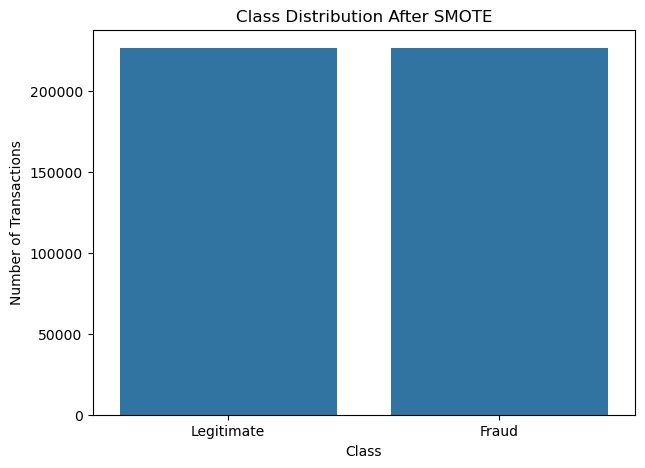

In [27]:
# Visualize the balanced training classes after SMOTE.
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_smote
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()


## 11. Train Logistic Regression

Logistic Regression is trained using the SMOTE-balanced training data.

In [28]:
# Train Logistic Regression on the SMOTE-balanced training data.
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = lr_model.predict(X_test)
lr_probability = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training completed!")


Logistic Regression training completed!


In [29]:
# Calculate evaluation metrics for Logistic Regression.
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_probability)
lr_pr_auc = average_precision_score(y_test, lr_probability)

print("LOGISTIC REGRESSION")
print("-------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))
print("PR-AUC   :", round(lr_pr_auc, 4))


LOGISTIC REGRESSION
-------------------------
Accuracy : 0.9737
Precision: 0.053
Recall   : 0.8737
F1 Score : 0.1
ROC-AUC  : 0.9619
PR-AUC   : 0.6769


## 12. Train Decision Tree

The Decision Tree uses `class_weight="balanced"` to account for the imbalanced class distribution in the original training data.

In [30]:
# Train a class-weighted Decision Tree on the original training data.
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_probability = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree training completed!")


Decision Tree training completed!


In [31]:
# Calculate evaluation metrics for the Decision Tree.
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_probability)
dt_pr_auc = average_precision_score(y_test, dt_probability)

print("DECISION TREE")
print("-------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_auc, 4))
print("PR-AUC   :", round(dt_pr_auc, 4))


DECISION TREE
-------------------------
Accuracy : 0.9953
Precision: 0.232
Recall   : 0.7789
F1 Score : 0.3575
ROC-AUC  : 0.8886
PR-AUC   : 0.5035


## 13. Train Random Forest

The Random Forest uses class weighting to give greater importance to the minority fraud class.

In [32]:
# Train the Random Forest model.
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_probability = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training completed!")


Random Forest training completed!


In [33]:
# Calculate evaluation metrics for the Random Forest.
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_probability)
rf_pr_auc = average_precision_score(y_test, rf_probability)

print("RANDOM FOREST")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))
print("PR-AUC   :", round(rf_pr_auc, 4))


RANDOM FOREST
-------------------------
Accuracy : 0.9995
Precision: 0.9853
Recall   : 0.7053
F1 Score : 0.8221
ROC-AUC  : 0.9346
PR-AUC   : 0.8064


## 14. Compare Model Performance

The models are compared using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and PR-AUC.

For fraud detection, Precision and Recall are particularly useful because the classes are highly imbalanced.

In [34]:
# Create a table containing the evaluation metrics for all models.
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc
    ],
    "PR-AUC": [
        lr_pr_auc,
        dt_pr_auc,
        rf_pr_auc
    ]
})

results.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9737,0.0530,0.8737,0.1000,0.9619,0.6769
1,Decision Tree,0.9953,0.2320,0.7789,0.3575,0.8886,0.5035
2,Random Forest,0.9995,0.9853,0.7053,0.8221,0.9346,0.8064


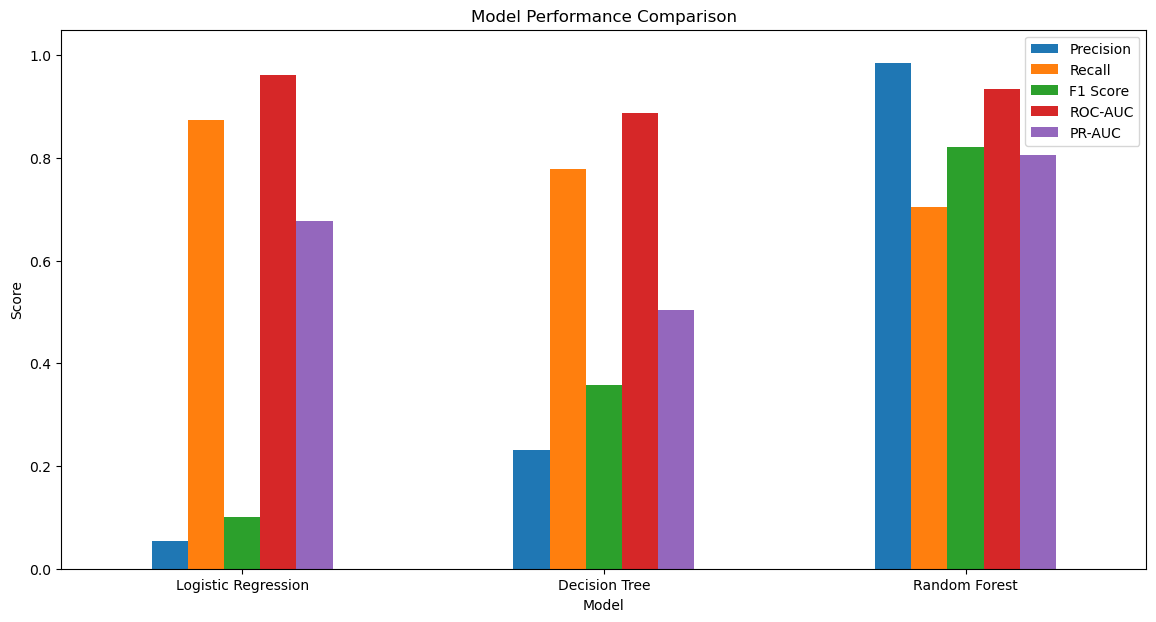

In [35]:
# Plot the main model evaluation metrics.
results_plot = results.set_index("Model")

results_plot[
    ["Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()


## 15. Random Forest Classification Report

In [36]:
# Display detailed precision, recall, and F1-score results for Random Forest.
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Legitimate", "Fraud"]
    )
)


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.99      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



## 16. Confusion Matrix

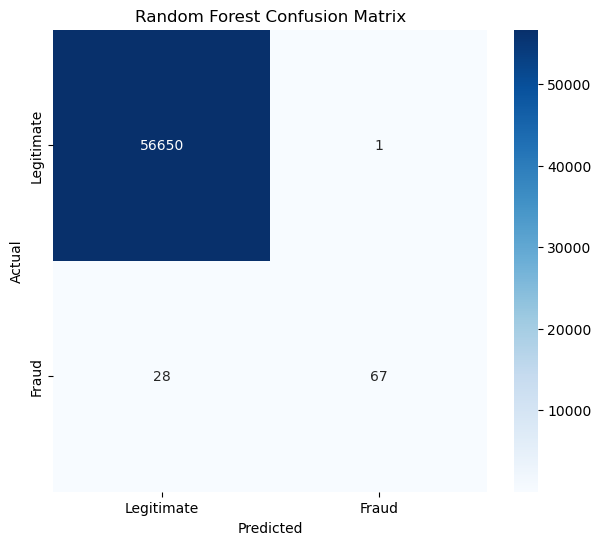

In [37]:
# Generate the Random Forest confusion matrix.
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()


## 17. ROC Curve

The ROC curve shows the relationship between the true positive rate and false positive rate across classification thresholds.

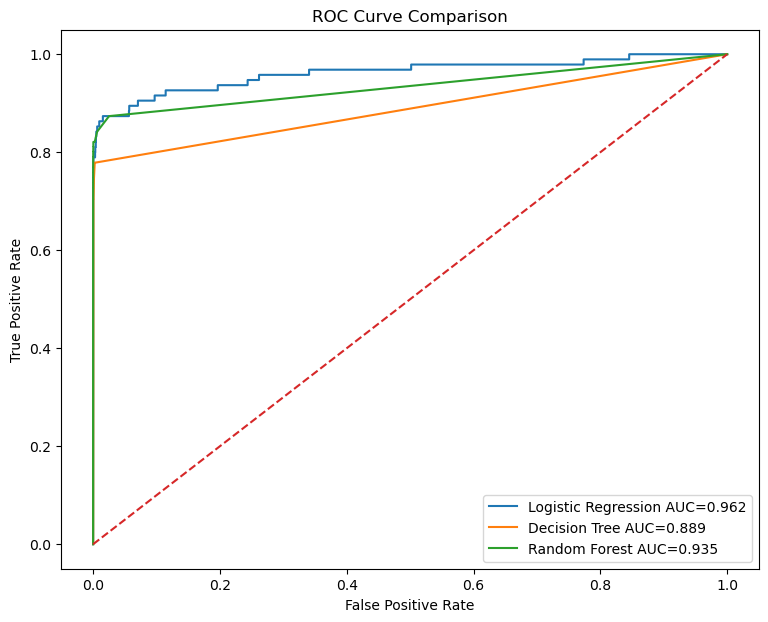

In [38]:
# Calculate and plot ROC curves for all three models.
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probability)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probability)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probability)

plt.figure(figsize=(9, 7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression AUC={lr_auc:.3f}"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree AUC={dt_auc:.3f}"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC={rf_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()


## 18. Precision-Recall Curve

The Precision-Recall curve is especially informative for imbalanced classification because it focuses on precision and recall for the positive class.

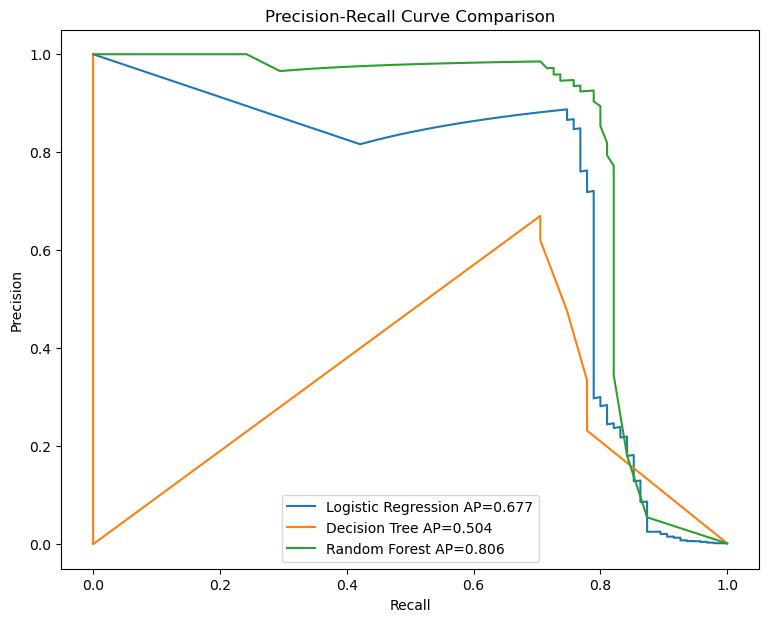

In [39]:
# Calculate and plot Precision-Recall curves for all three models.
lr_precision_curve, lr_recall_curve, _ = precision_recall_curve(
    y_test,
    lr_probability
)

dt_precision_curve, dt_recall_curve, _ = precision_recall_curve(
    y_test,
    dt_probability
)

rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(
    y_test,
    rf_probability
)

plt.figure(figsize=(9, 7))

plt.plot(
    lr_recall_curve,
    lr_precision_curve,
    label=f"Logistic Regression AP={lr_pr_auc:.3f}"
)

plt.plot(
    dt_recall_curve,
    dt_precision_curve,
    label=f"Decision Tree AP={dt_pr_auc:.3f}"
)

plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    label=f"Random Forest AP={rf_pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()


## 19. Random Forest Feature Importance

Feature importance shows which input features contributed most to the Random Forest's predictions.

The dataset contains anonymized feature names such as `V1` to `V28`; their names are retained as provided by the dataset.

In [40]:
# Create a table of Random Forest feature importances.
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)


,Feature,Importance
14,V14,0.189455
10,V10,0.140624
12,V12,0.110843
4,V4,0.095371
17,V17,0.082103
3,V3,0.054968
16,V16,0.051584
11,V11,0.046368
2,V2,0.028395
7,V7,0.023757


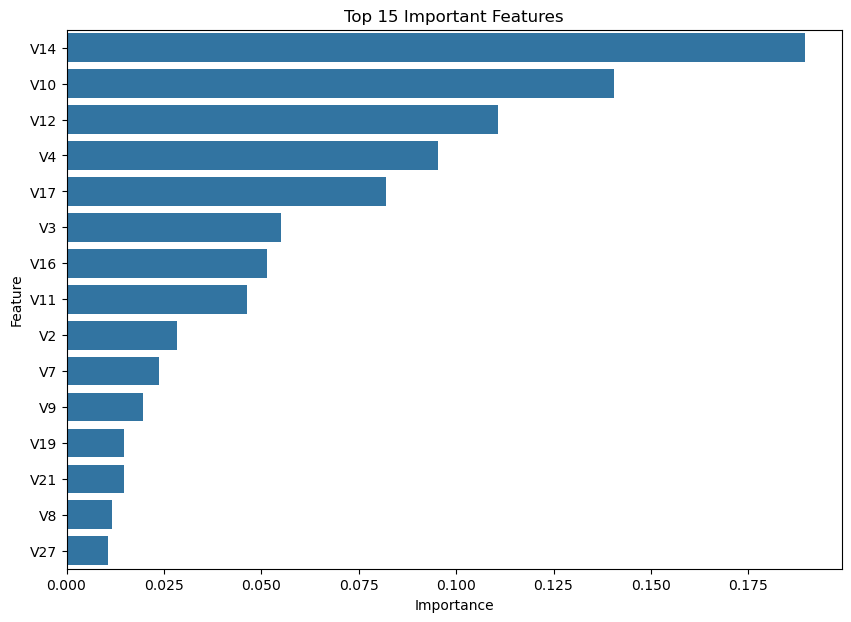

In [41]:
# Visualize the 15 most important features.
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()


## 20. Save the Trained Model

The trained Random Forest, scaler, and feature list are saved so they can be reused later for prediction.

In [42]:
# Create a folder for the saved model files.
os.makedirs(
    "fraud_model",
    exist_ok=True
)


In [43]:
# Save the trained Random Forest model.
joblib.dump(
    rf_model,
    "fraud_model/fraud_detection_model.pkl"
)


['fraud_model/fraud_detection_model.pkl']

In [44]:
# Save the fitted scaler used during preprocessing.
joblib.dump(
    scaler,
    "fraud_model/scaler.pkl"
)


['fraud_model/scaler.pkl']

In [45]:
# Save the feature names and their expected order.
joblib.dump(
    list(X.columns),
    "fraud_model/features.pkl"
)

print("All model files saved successfully!")


All model files saved successfully!


In [46]:
# Verify that the model files were created.
print(os.listdir("fraud_model"))


['features.pkl', 'fraud_detection_model.pkl', 'scaler.pkl']


## 21. Test a Sample Transaction

The following example uses one transaction from the test set to demonstrate how the trained Random Forest produces a prediction and fraud probability.

In [47]:
# Select one transaction from the test set and generate a prediction.
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]

prediction = rf_model.predict(sample)[0]
probability = rf_model.predict_proba(sample)[0][1]

print("Actual Class:", actual)
print("Predicted Class:", prediction)
print("Fraud Probability:", round(probability * 100, 2), "%")


Actual Class: 0
Predicted Class: 0
Fraud Probability: 0.0 %


In [48]:
# Display a human-readable prediction result.
if prediction == 1:
    print("FRAUDULENT TRANSACTION DETECTED")
else:
    print("LEGITIMATE TRANSACTION")


LEGITIMATE TRANSACTION


## 22. Conclusion

This notebook developed a credit card fraud detection workflow using three machine-learning models: Logistic Regression, Decision Tree, and Random Forest.

The workflow included data inspection, exploratory analysis, preprocessing, class-imbalance handling, model training, and multiple evaluation techniques. The Random Forest model and its preprocessing objects were saved in the `fraud_model` folder for reuse.

The final model should be evaluated using the reported fraud-class Precision, Recall, F1 Score, ROC-AUC, and PR-AUC rather than accuracy alone because fraud detection is an imbalanced classification problem.
